# Fake News Classification using RNN, LSTM and Word2Vec
### 6CS012 Final Portfolio Project 2026 — Part III
---

##  Step 0: Install Dependencies

In [1]:
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install contractions -q
!pip install wordcloud -q
print('All packages installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 83.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.0 MB/s eta 0:00:00
All packages installed!


## Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import contractions
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# WordCloud
from wordcloud import WordCloud

print('TensorFlow version:', tf.__version__)
print('All libraries imported successfully!')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.20.0
All libraries imported successfully!


## Step 2: Load Dataset


In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/truevsfakenews.csv')

print('Dataset shape:', df.shape)
df.head()

Mounted at /content/drive
Dataset shape: (20000, 2)


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [4]:
print('Columns:', df.columns.tolist())
print('\nLabel distribution:')
print(df['label'].value_counts())

print('\nMissing values:')
print(df.isnull().sum())

df.dropna(subset=['text', 'label'], inplace=True)
df.reset_index(drop=True, inplace=True)
print('\nCleaned dataset shape:', df.shape)

Columns: ['text', 'label']

Label distribution:
label
true    10000
fake    10000
Name: count, dtype: int64

Missing values:
text     0
label    0
dtype: int64

Cleaned dataset shape: (20000, 2)


Label encoding:
label_encoded
1    10000
0    10000
Name: count, dtype: int64


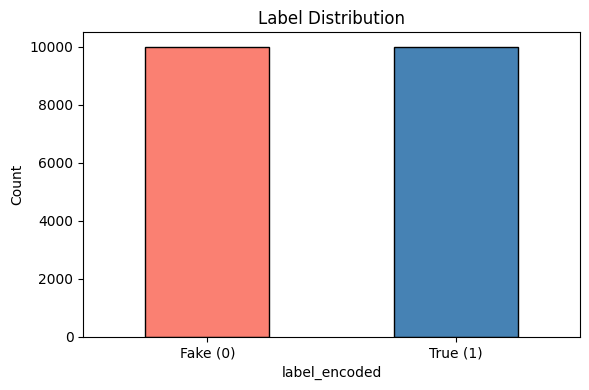

In [5]:
df['label_encoded'] = df['label'].str.strip().str.upper().map({'TRUE': 1, 'FAKE': 0})


print('Label encoding:')
print(df['label_encoded'].value_counts())

plt.figure(figsize=(6,4))
df['label_encoded'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.xticks([0, 1], ['Fake (0)', 'True (1)'], rotation=0)
plt.title('Label Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Task 1: Text Preprocessing

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions (don't -> do not)
    text = contractions.fix(text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove mentions (@user) and hashtags (#tag)
    text = re.sub(r'@\w+|#\w+', '', text)

    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 6. Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return ' '.join(tokens)

print('Cleaning text...')
df['cleaned_text'] = df['text'].astype(str).apply(clean_text)
print('Done!')

# Preview
print('\nOriginal:')
print(df['text'].iloc[0][:200])
print('\nCleaned:')
print(df['cleaned_text'].iloc[0][:200])

Cleaning text... (this may take a minute)
Done!

Original:
WASHINGTON (Reuters) - The Republican and Democratic leaders of the U.S. Senate Foreign Relations Committee blasted the U.S. State Department on Tuesday for cuts in staff and what they described as a 

Cleaned:
washington reuters republican democratic leader yous senate foreign relation committee blasted yous state department tuesday cut staff described failure plan proposed reorganization think anywhere clo


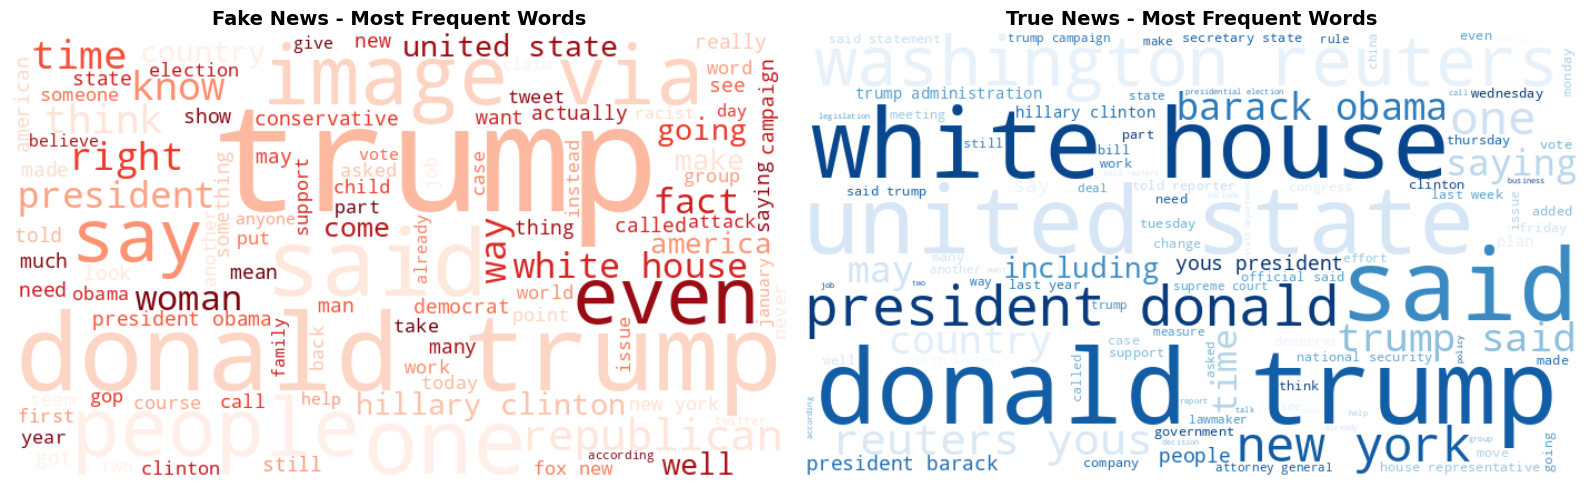

In [7]:
# ---- Word Cloud ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fake news word cloud
fake_text = ' '.join(df[df['label_encoded'] == 0]['cleaned_text'])
wc_fake = WordCloud(width=700, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Fake News - Most Frequent Words', fontsize=14, fontweight='bold')

# True news word cloud
true_text = ' '.join(df[df['label_encoded'] == 1]['cleaned_text'])
wc_true = WordCloud(width=700, height=400, background_color='white',
                    colormap='Blues', max_words=100).generate(true_text)
axes[1].imshow(wc_true, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('True News - Most Frequent Words', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

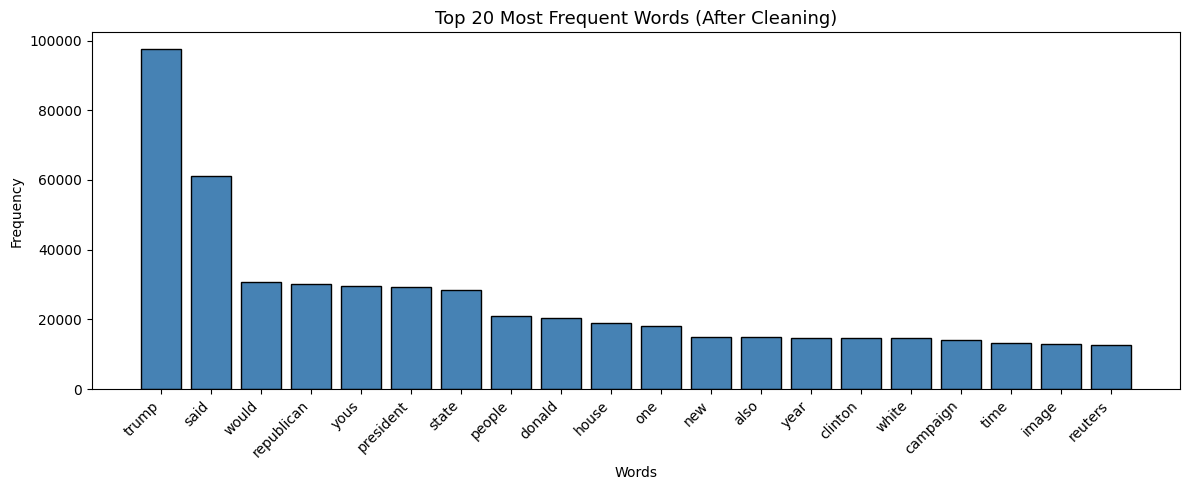

In [8]:
# ---- Top 20 Most Frequent Words ----
from collections import Counter

all_words = ' '.join(df['cleaned_text']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words (After Cleaning)', fontsize=13)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  Task 1b: Train/Test Split, Tokenization & Padding

In [9]:
# ---- Train/Test Split ----
X = df['cleaned_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 16000
Testing samples:  4000


In [10]:
# ---- Keras Tokenizer ----
VOCAB_SIZE = 20000  # Use top 20k words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # Fit ONLY on training data

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
print(f'Vocabulary size (unique words found): {len(word_index)}')
print(f'Using top {VOCAB_SIZE} words')

Vocabulary size (unique words found): 104359
Using top 20000 words


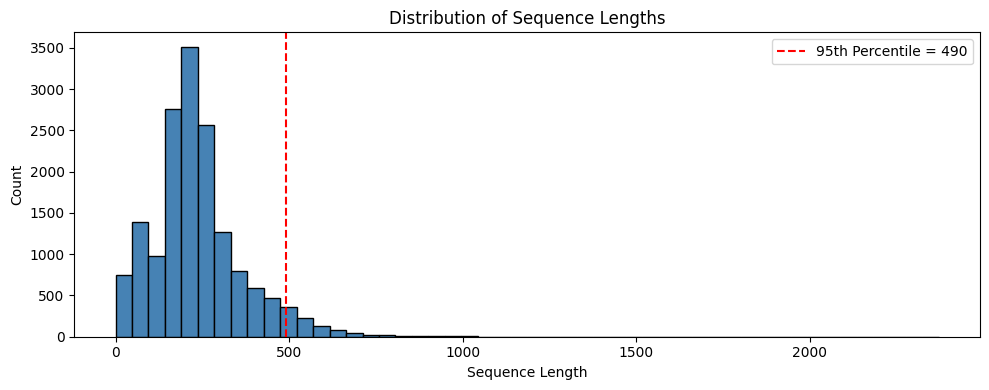

Using MAX_LEN = 490 (95th percentile)


In [11]:
# ---- Percentile-based Padding ----
seq_lengths = [len(s) for s in X_train_seq]

plt.figure(figsize=(10,4))
plt.hist(seq_lengths, bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='--',
            label=f'95th Percentile = {int(np.percentile(seq_lengths, 95))}')
plt.legend()
plt.tight_layout()
plt.show()

MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f'Using MAX_LEN = {MAX_LEN} (95th percentile)')

In [12]:
# ---- Apply Padding ----
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad shape:  {X_test_pad.shape}')

X_train_pad shape: (16000, 490)
X_test_pad shape:  (4000, 490)


##  Task 2: Build Three Models
### Model 1 — Simple RNN with Trainable Embedding

In [13]:
EMBEDDING_DIM = 64

# ---- MODEL 1: Simple RNN ----
model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model1.add(SimpleRNN(64, return_sequences=False))
model1.add(Dropout(0.3))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))  # Binary classification

model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

In [14]:
# ---- MODEL 2: LSTM ----
model2 = Sequential(name='LSTM_Model')
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pretrained GloVe / Word2Vec Embeddings

In [15]:
# ---- Download Pretrained GloVe Embeddings via Gensim ----
import gensim.downloader as api

print('Downloading GloVe embeddings (glove-wiki-gigaword-50)...')
print('This will take a few minutes on first run...')
embedding_model = api.load('glove-wiki-gigaword-50')  # 50-dimensional
print('GloVe embeddings loaded!')

This will take a few minutes on first run...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded!


In [16]:
# ---- Build Embedding Matrix ----
GLOVE_DIM = 50  # Must match the downloaded model

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found = 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

print(f'Words found in GloVe: {found} / {min(VOCAB_SIZE, len(word_index))}')
print(f'Coverage: {found / min(VOCAB_SIZE, len(word_index)) * 100:.1f}%')

Words found in GloVe: 18282 / 20000
Coverage: 91.4%


In [17]:
# ---- MODEL 3: LSTM with Pretrained GloVe ----
model3 = Sequential(name='LSTM_GloVe_Model')
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False  # Frozen pretrained weights
))
model3.add(LSTM(64, return_sequences=False))
model3.add(Dropout(0.3))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

##  Task 3: Train All Models

In [18]:
# ---- Training Config ----
EPOCHS    = 20
BATCH_SIZE = 64

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [19]:
# ---- Train Model 1 ----
print('Training Model 1: Simple RNN...')
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('Model 1 training complete!')

Training Model 1: Simple RNN...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.5184 - loss: 0.6911 - val_accuracy: 0.5369 - val_loss: 0.6781
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.5291 - loss: 0.6802 - val_accuracy: 0.5369 - val_loss: 0.6775
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5343 - loss: 0.6749 - val_accuracy: 0.5375 - val_loss: 0.6732
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.5383 - loss: 0.6667 - val_accuracy: 0.5350 - val_loss: 0.6755
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.5375 - loss: 0.6659 - val_accuracy: 0.5350 - val_loss: 0.6732
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.5337 - loss: 0.6627 - val_accuracy: 0.5356 - val_loss: 0.6718
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5438 - loss: 0.6598 - val_accuracy: 0.5356 - val_loss: 0.6797
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accurac

In [20]:
# ---- Train Model 2 ----
print('Training Model 2: LSTM...')
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('Model 2 training complete!')

Training Model 2: LSTM...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5384 - loss: 0.6841 - val_accuracy: 0.5412 - val_loss: 0.6715
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5390 - loss: 0.6690 - val_accuracy: 0.5406 - val_loss: 0.6685
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.5715 - loss: 0.6561 - val_accuracy: 0.8750 - val_loss: 0.4149
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8339 - loss: 0.3903 - val_accuracy: 0.8469 - val_loss: 0.3728
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8348 - loss: 0.3911 - val_accuracy: 0.8781 - val_loss: 0.3267
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.8211 - loss: 0.3855 - val_accuracy: 0.9087 - val_loss: 0.3046
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9552 - loss: 0.1603 - val_accuracy: 0.9762 - val_loss: 0.0861
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.979

In [21]:
# ---- Train Model 3 ----
print('Training Model 3: LSTM + GloVe...')
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('Model 3 training complete!')

Training Model 3: LSTM + GloVe...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5760 - loss: 0.6639 - val_accuracy: 0.7331 - val_loss: 0.5250
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7841 - loss: 0.4601 - val_accuracy: 0.8100 - val_loss: 0.4206
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7951 - loss: 0.4289 - val_accuracy: 0.8444 - val_loss: 0.3741
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Model 3 training complete!


##  Task 3b: Training Curves — Loss & Accuracy

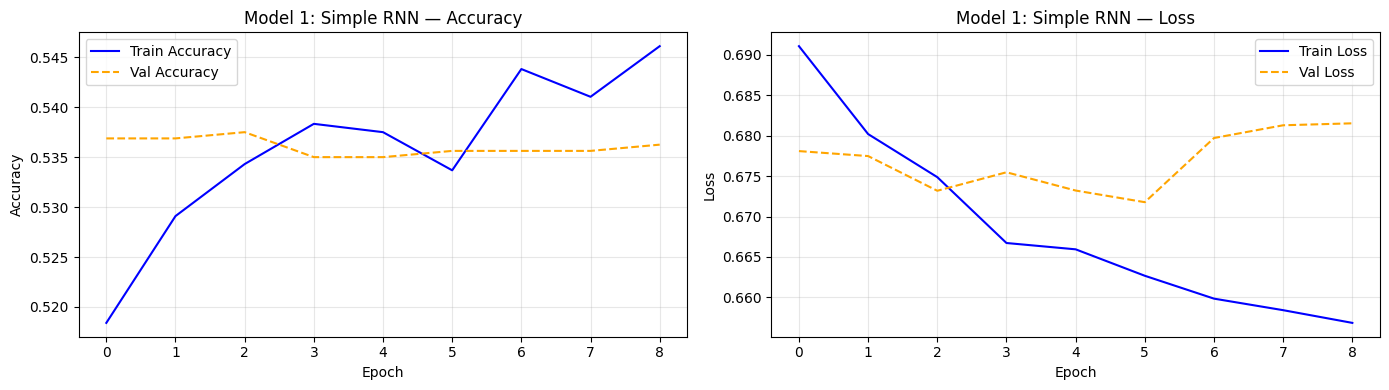

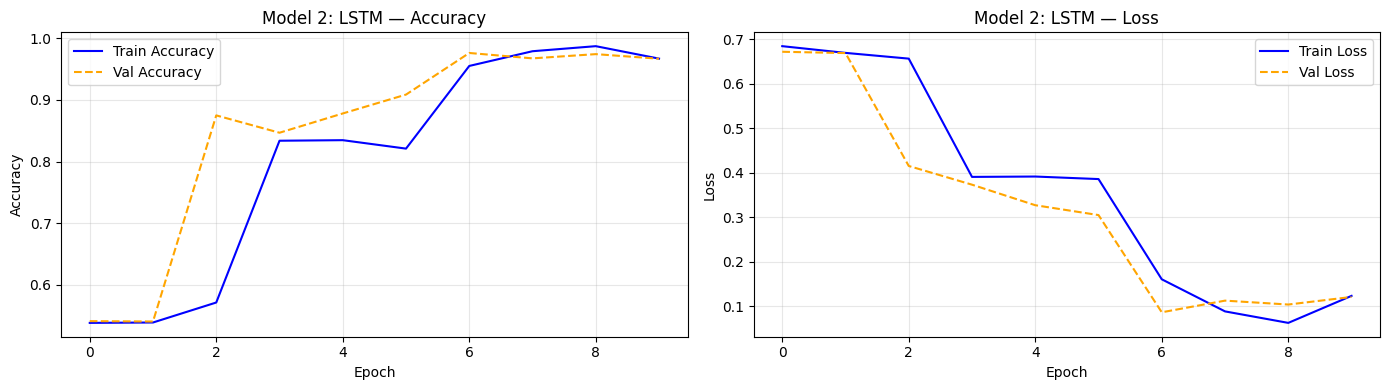

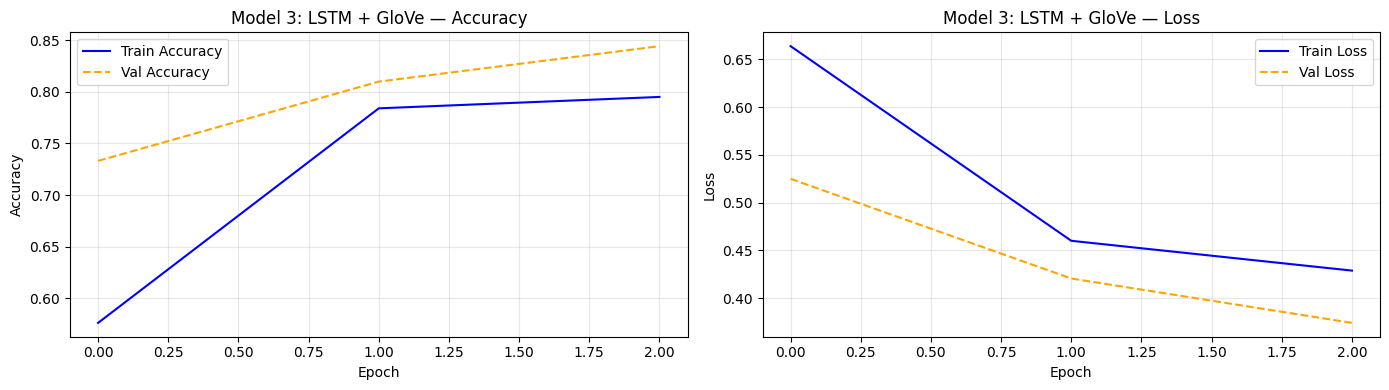

In [22]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history1, 'Model 1: Simple RNN')
plot_history(history2, 'Model 2: LSTM')
plot_history(history3, 'Model 3: LSTM + GloVe')

## Task 3c: Evaluate All Models


  Model 1: Simple RNN

Accuracy: 0.5375 (53.75%)

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.52      0.99      0.68      2000
    True (1)       0.86      0.09      0.16      2000

    accuracy                           0.54      4000
   macro avg       0.69      0.54      0.42      4000
weighted avg       0.69      0.54      0.42      4000



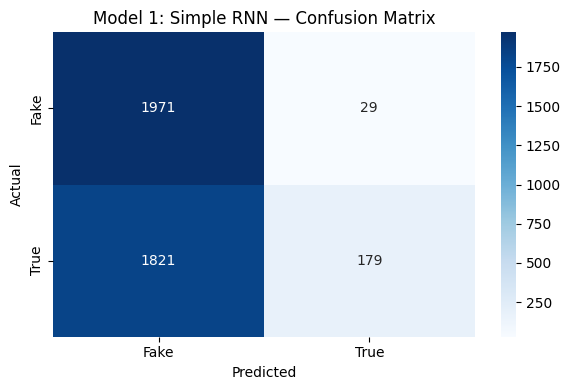


  Model 2: LSTM

Accuracy: 0.9692 (96.92%)

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.97      0.97      0.97      2000
    True (1)       0.97      0.97      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



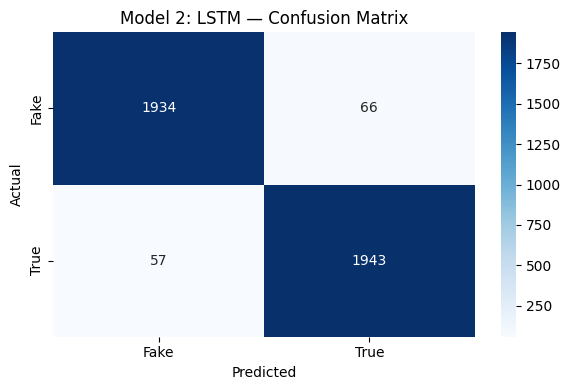


  Model 3: LSTM + GloVe

Accuracy: 0.7385 (73.85%)

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.66      0.98      0.79      2000
    True (1)       0.96      0.50      0.66      2000

    accuracy                           0.74      4000
   macro avg       0.81      0.74      0.72      4000
weighted avg       0.81      0.74      0.72      4000



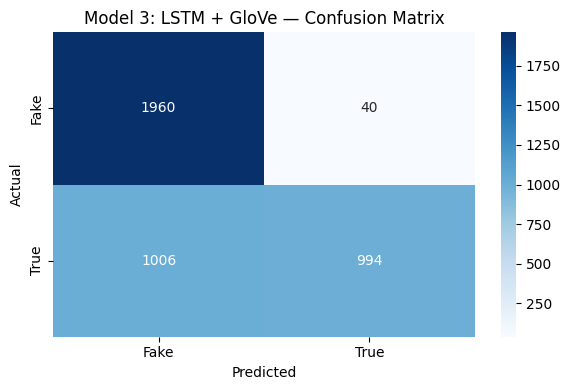

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f'\n{'='*50}')
    print(f'  {model_name}')
    print(f'{'='*50}')

    # Predict
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f'\nAccuracy: {acc:.4f} ({acc*100:.2f}%)')

    # Classification Report
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'True (1)']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'True'],
                yticklabels=['Fake', 'True'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1: Simple RNN')
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2: LSTM')
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3: LSTM + GloVe')

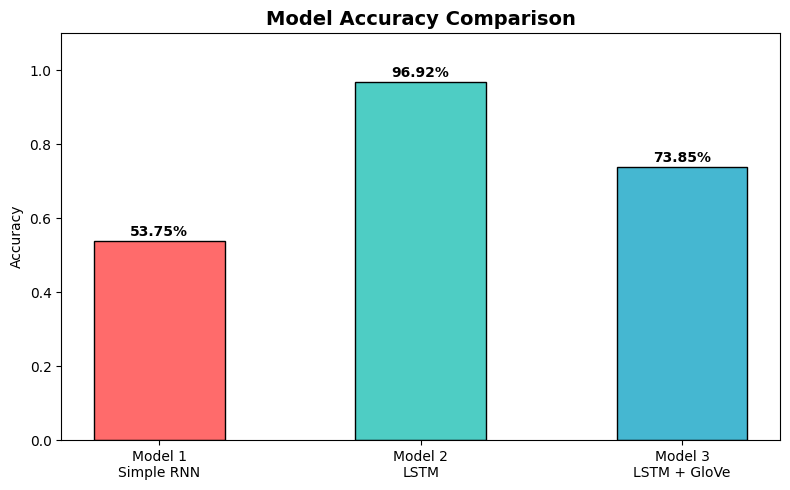


Model 1 (Simple RNN): 53.75%
Model 2 (LSTM):       96.92%
Model 3 (LSTM+GloVe): 73.85%


In [24]:
# ---- Side-by-side Accuracy Comparison ----
models = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accuracies = [acc1, acc2, acc3]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

print(f'\nModel 1 (Simple RNN): {acc1*100:.2f}%')
print(f'Model 2 (LSTM):       {acc2*100:.2f}%')
print(f'Model 3 (LSTM+GloVe): {acc3*100:.2f}%')

##  Task 4: Error Analysis

In [25]:
# Use best model's predictions (Model 2 or 3 typically best)
best_pred = pred2  # Change to pred3 if Model 3 is better

# Find misclassified examples
misclassified_idx = np.where(best_pred != y_test)[0]
print(f'Total misclassified: {len(misclassified_idx)} / {len(y_test)}')
print()

# Show 3 examples
for i, idx in enumerate(misclassified_idx[:3]):
    print(f'--- Misclassified Example {i+1} ---')
    print(f'Original text (first 200 chars): {X_test[idx][:200]}')
    print(f'Cleaned text:  {X_test[idx][:150]}')
    print(f'True label:    {"TRUE" if y_test[idx] == 1 else "FAKE"}')
    print(f'Predicted:     {"TRUE" if best_pred[idx] == 1 else "FAKE"}')
    print()

Total misclassified: 123 / 4000

--- Misclassified Example 1 ---
Original text (first 200 chars): picture snapped white house photographer traveling president left golf course sterling went viral almost immediately news outlet picked story appeared white house pool report latenight talk show host 
Cleaned text:  picture snapped white house photographer traveling president left golf course sterling went viral almost immediately news outlet picked story appeared
True label:    FAKE
Predicted:     TRUE

--- Misclassified Example 2 ---
Original text (first 200 chars): another winner america president trump supreme court ruled favor travel ban guess voted justice ruth bader ginsburg sonia sotomayor said would left lower court order place anyone surprised two lefty j
Cleaned text:  another winner america president trump supreme court ruled favor travel ban guess voted justice ruth bader ginsburg sonia sotomayor said would left lo
True label:    FAKE
Predicted:     TRUE

--- Misclassified Exa

In [30]:
# ---- Error Analysis Summary ----
print('''
ERROR ANALYSIS SUMMARY
======================

Possible reasons for misclassification:

1. Short texts: Very short articles may not contain enough context
   for the model to distinguish fake from real.

2. Ambiguous language: Some fake news mimics real news writing style,
   making it harder for the model to differentiate.

3. Out-of-vocabulary words: Words not seen during training get
   mapped to <OOV> token, losing important semantic information.

4. Vanishing gradient (RNN): Simple RNN struggles with long-term
   dependencies in long articles — LSTM handles this better.


''')


ERROR ANALYSIS SUMMARY

Possible reasons for misclassification:

1. Short texts: Very short articles may not contain enough context
   for the model to distinguish fake from real.

2. Ambiguous language: Some fake news mimics real news writing style,
   making it harder for the model to differentiate.

3. Out-of-vocabulary words: Words not seen during training get
   mapped to <OOV> token, losing important semantic information.

4. Vanishing gradient (RNN): Simple RNN struggles with long-term
   dependencies in long articles — LSTM handles this better.





##  Task 5

In [29]:
!pip install gradio -q
import gradio as gr

def predict_news(text):
    # Clean the input text
    cleaned = clean_text(str(text))

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict with best model (Model 2)
    prob = model2.predict(padded, verbose=0)[0][0]
    label = 'TRUE NEWS ' if prob > 0.5 else 'FAKE NEWS '
    confidence = prob if prob > 0.5 else 1 - prob

    return f'{label}\nConfidence: {confidence*100:.1f}%'

# Create Gradio Interface
demo = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=5, placeholder='Paste a news article here...', label='News Text'),
    outputs=gr.Textbox(label='Prediction'),
    title='Fake News Detector ',
    description='Enter any news article text and the model will classify it as TRUE or FAKE.',
    examples=[
        ['The president signed a new bill today related to healthcare reform.'],
        ['BREAKING: Scientists discover that drinking bleach cures all diseases!'],
    ]
)

demo.launch(share=True)  # share=True gives a public URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ec38199094f3abb0aa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## ✅ Summary

| Task | Status |
|------|--------|
| Text Preprocessing (lowercase, clean, lemmatize) | ✅ Done |
| Visualization (WordCloud, frequency bar) | ✅ Done |
| Train/Test Split (80/20) | ✅ Done |
| Tokenization & Padding (percentile-based) | ✅ Done |
| Model 1: Simple RNN | ✅ Done |
| Model 2: LSTM | ✅ Done |
| Model 3: LSTM + GloVe Embeddings | ✅ Done |
| Training with EarlyStopping | ✅ Done |
| Accuracy, Confusion Matrix, Classification Report | ✅ Done |
| Model Comparison Plot | ✅ Done |
| Error Analysis | ✅ Done |
| GUI (Gradio) | ✅ Done |